In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import sys
# from umap import UMAP
import joblib
import pandas as pd

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE




In [3]:
ae = torch.load('/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_front_localmax_correctloader_ch1_ps16_latdim_8_20251015_1314/ae_model_ep9999.pt', map_location=device, weights_only=False)

ae = ae.to(device)
ae.eval()

AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=8, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=8, out_features=1024,

In [4]:
recon_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/recon_pax_front_localmax_correctloader_ch1_ps16_latdim_8_20251015_1314'
os.makedirs(recon_dir, exist_ok=True)

raw_grid_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/raw_grid_pax_front_localmax_correctloader_ch1_ps16_latdim_8_20251015_1314'
os.makedirs(raw_grid_dir, exist_ok=True)

raw_patch_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/raw_patch_pax_front_localmax_correctloader_ch1_ps16_latdim_8_20251015_1314'
os.makedirs(raw_patch_dir, exist_ok=True)

recon_patch_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/recon_patch_pax_front_localmax_correctloader_ch1_ps16_latdim_8_20251015_1314'
os.makedirs(recon_patch_dir, exist_ok=True)




In [5]:
patch_label_df = pd.DataFrame(columns=['ctrl_y_str','crop_img_filename','group_labels','UMAP_d0','UMAP_d1','DBSCAN_labels','kmeans_labels'])


In [6]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_localmax_rotation_pslocation00/plot_patches16_65p_20251015_1131'
csv_filename = 'data_prep_record_49_t49.csv'
group_labels = 0
ctrl_y_str = 'ctrl'
all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()
latent_array =  []

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
   
    for index, row in this_file_csv.iterrows():        
        patch_name = row['crop_img_filename']
        raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
        normed_raw_patch = raw_patch.copy() * 240 
        normed_raw_patch[normed_raw_patch > 254] = 254
        normed_raw_patch = normed_raw_patch/255
        tensor_patch = torch.from_numpy(normed_raw_patch)
        tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
        tensor_patch = tensor_patch.to(device)
        
        with torch.no_grad():
            recon_image, latent = ae(tensor_patch)
        latent_array.append(latent)  

        s = pd.Series([ctrl_y_str, patch_name, group_labels, 0,0,0,0],
            index=['ctrl_y_str','crop_img_filename','group_labels','UMAP_d0','UMAP_d1','DBSCAN_labels','kmeans_labels'])
            
        patch_label_df = pd.concat([patch_label_df, s.to_frame().T], ignore_index=True)


In [8]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_localmax_norotation_pslocation00/plot_patches16_65p_20251015_1143'
csv_filename = 'data_prep_record_40_t40.csv'
group_labels = 1
ctrl_y_str = 'y'

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
   
    for index, row in this_file_csv.iterrows():        
        patch_name = row['crop_img_filename']
        raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
        normed_raw_patch = raw_patch.copy() * 240 
        normed_raw_patch[normed_raw_patch > 254] = 254
        normed_raw_patch = normed_raw_patch/255
        tensor_patch = torch.from_numpy(normed_raw_patch)
        tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
        tensor_patch = tensor_patch.to(device)
        
        with torch.no_grad():
            recon_image, latent = ae(tensor_patch)
        latent_array.append(latent)  

        s = pd.Series([ctrl_y_str, patch_name, group_labels, 0,0,0,0],
            index=['ctrl_y_str','crop_img_filename','group_labels','UMAP_d0','UMAP_d1','DBSCAN_labels','kmeans_labels'])
            
        patch_label_df = pd.concat([patch_label_df, s.to_frame().T], ignore_index=True)


In [9]:
patch_label_df

,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels
0,ctrl,f0000x0472y0280ps16.tif,0,0,0,0,0
1,ctrl,f0000x0488y0296ps16.tif,0,0,0,0,0
2,ctrl,f0000x0504y0312ps16.tif,0,0,0,0,0
3,ctrl,f0000x0504y0328ps16.tif,0,0,0,0,0
4,ctrl,f0000x0520y0360ps16.tif,0,0,0,0,0
...,...,...,...,...,...,...,...
16504,y,f0040x0920y0664ps16.tif,1,0,0,0,0
16505,y,f0040x0920y0696ps16.tif,1,0,0,0,0
16506,y,f0040x0920y0712ps16.tif,1,0,0,0,0
16507,y,f0040x0920y0728ps16.tif,1,0,0,0,0


In [10]:
latent_array_np = torch.stack(latent_array).detach().cpu().numpy().squeeze()
print(latent_array_np.shape)

(16509, 8)


In [11]:
joblib.dump(os.path.join(recon_dir, 'latent_array_np.pkl'),'latent_array_np')
patch_label_df.to_csv(os.path.join(recon_dir, 'patch_label_df.csv'))

In [12]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, dataloader_model_latents,kmeans_cluster,DBSCAN_cluster
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot

In [38]:
eps=20
min_samples=10
result_dir = '../results/ctrl_y_ch1_patches_localmax_ps16_location00_lat8'
os.makedirs(result_dir, exist_ok=True)


In [39]:
DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latent_array_np, eps=eps, min_samples=min_samples, result_dir=result_dir)


(array([   88.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 16421.]),
 array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ]),
 <BarContainer object of 10 artists>)

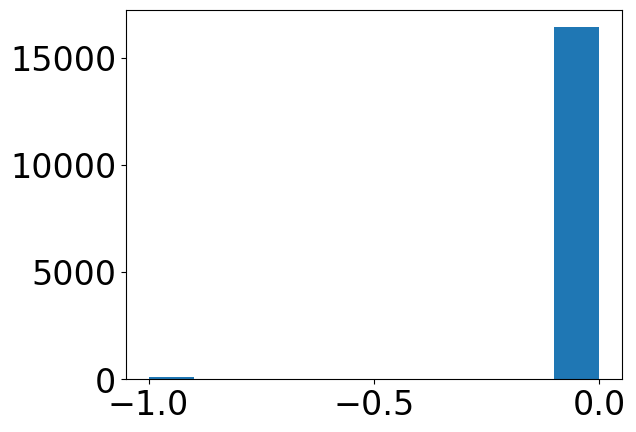

In [40]:
plt.hist(DBSCAN_labels)

In [15]:
kmeans_num_clusters=30
kmeans, kmeans_labels = kmeans_cluster(latent_array_np, num_clusters=kmeans_num_clusters, result_dir=result_dir)


(array([2634.,  743.,  354., 8751., 1186.,  149., 1051.,  300.,  589.,
         752.]),
 array([ 0. ,  2.9,  5.8,  8.7, 11.6, 14.5, 17.4, 20.3, 23.2, 26.1, 29. ]),
 <BarContainer object of 10 artists>)

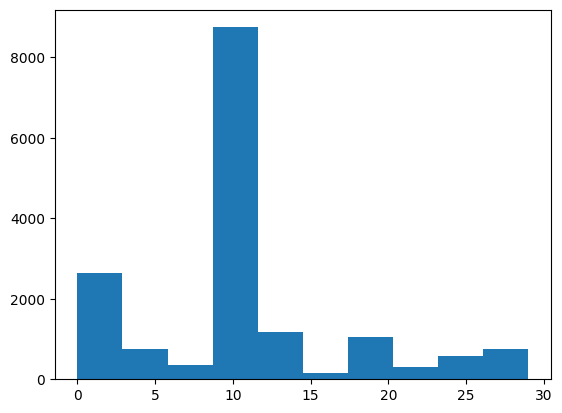

In [16]:
plt.hist(kmeans_labels)

In [ ]:
patch_label_df['kmeans_labels']= kmeans_labels
patch_label_df['DBSCAN_labels']= DBSCAN_labels



In [43]:
latents_2d.shape

(16509, 2)

In [46]:
patch_label_df['UMAP_d1']= latents_2d[:,0]
patch_label_df['UMAP_d2']= latents_2d[:,1]

In [47]:
patch_label_df.to_csv(os.path.join(recon_dir, 'patch_label_df.csv'))

In [42]:
patch_label_df

,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels
0,ctrl,f0000x0472y0280ps16.tif,0,0,0,0,13
1,ctrl,f0000x0488y0296ps16.tif,0,0,0,0,13
2,ctrl,f0000x0504y0312ps16.tif,0,0,0,0,20
3,ctrl,f0000x0504y0328ps16.tif,0,0,0,0,10
4,ctrl,f0000x0520y0360ps16.tif,0,0,0,0,10
...,...,...,...,...,...,...,...
16504,y,f0040x0920y0664ps16.tif,1,0,0,0,10
16505,y,f0040x0920y0696ps16.tif,1,0,0,0,0
16506,y,f0040x0920y0712ps16.tif,1,0,0,0,10
16507,y,f0040x0920y0728ps16.tif,1,0,0,0,10


In [17]:
latents_2d = UMAP_train(latent_array_np, result_dir)

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [18]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_latents_2d = tsne.fit_transform(latent_array_np)

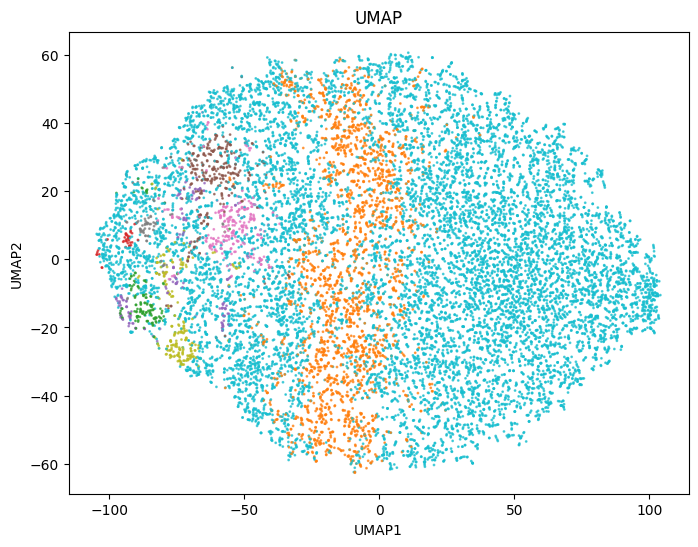

In [19]:
fig = umap_2Dplot(tsne_latents_2d, 0,1,kmeans_labels)

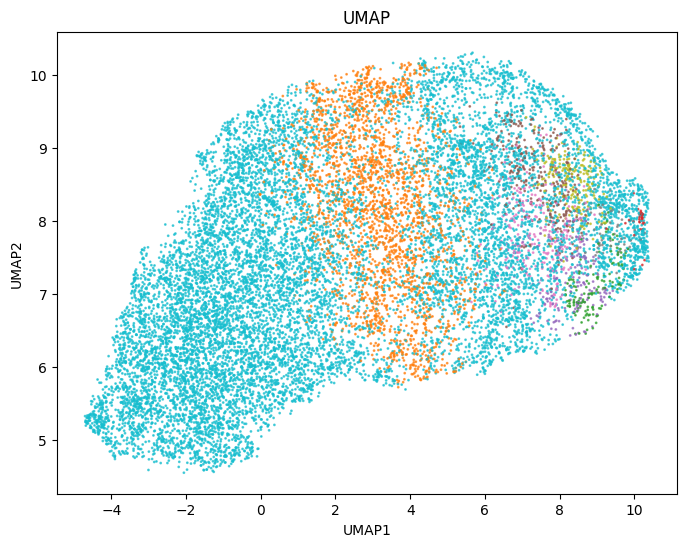

In [20]:
fig = umap_2Dplot(latents_2d, 0,1,kmeans_labels)

In [21]:
group_labels = patch_label_df['group_labels']

latents_2d[group_labels==0].shape

(9953, 2)

Text(0, 0.5, 'UMAP2')

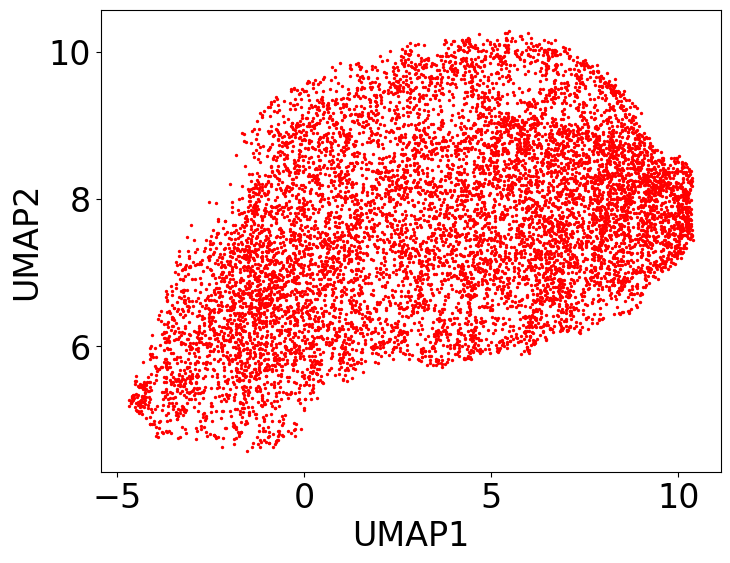

In [22]:
ctrl_latents_2d= latents_2d[group_labels==0]
y_latents_2d= latents_2d[group_labels==1]
# fig = umap_2Dplot(latents_2d[group_labels==1], 0,1,group_labels[group_labels==1]+2)
plt.rcParams.update({'font.size': 24})

fig = plt.figure(figsize=(8, 6))
plt.scatter(ctrl_latents_2d[:, 0], ctrl_latents_2d[:, 1], c='red',  s=2)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
# plt.title("UMAP")  

Text(0, 0.5, 'UMAP2')

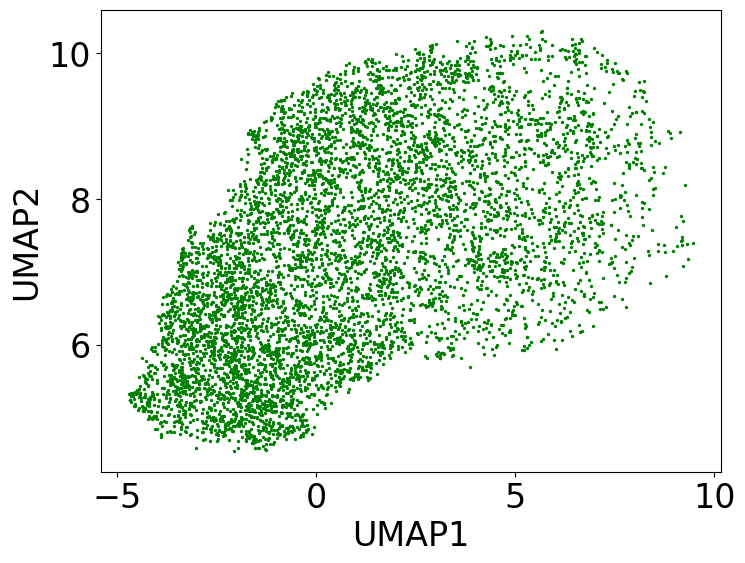

In [23]:

ctrl_latents_2d= latents_2d[group_labels==0]
y_latents_2d= latents_2d[group_labels==1]
# fig = umap_2Dplot(latents_2d[group_labels==1], 0,1,group_labels[group_labels==1]+2)
plt.rcParams.update({'font.size': 24})

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_latents_2d[:, 0], y_latents_2d[:, 1], c='green',  s=2)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
# plt.title("UMAP")  


In [50]:
patch_label_df[patch_label_df['crop_img_filename']==patch_name]['UMAP_d0']
patch_label_df[patch_label_df['crop_img_filename']==patch_name]['UMAP_d1']


9952   -0.669977
Name: UMAP_d1, dtype: float32

In [55]:
UMAP_d0.iloc[0]

0

In [63]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_localmax_rotation_pslocation00/plot_patches16_65p_20251015_1131'
csv_filename = 'data_prep_record_49_t49.csv'

pad_size = 64
import pandas as pd

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()
latent_array =  []
index_count=-1

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
    # print(csv_filename)
    # raw_whole_image = np.zeros([1024,1024])
    # recon_whole_image = np.zeros([1024,1024])    
    # raw_whole_image_RGB = np.zeros([3,1024,1024])
    # recon_whole_image_RGB = np.zeros([3,1024,1024])    

    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']
        patch_label_df[patch_label_df['crop_img_filename']==patch_name]
        UMAP_d0 = patch_label_df[patch_label_df['crop_img_filename']==patch_name]['UMAP_d1']
        UMAP_d1 = patch_label_df[patch_label_df['crop_img_filename']==patch_name]['UMAP_d2']
        print(UMAP_d1.iloc[0])
        if UMAP_d1.iloc[0] >4.8:
            continue
            
                
        raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
        normed_raw_patch = raw_patch.copy() * 240 
        normed_raw_patch[normed_raw_patch > 254] = 254
        normed_raw_patch = normed_raw_patch/255
        
        tensor_patch = torch.from_numpy(normed_raw_patch)
        tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
        tensor_patch = tensor_patch.to(device)
        ae = ae.to(device)
        with torch.no_grad():
            recon_image, latent = ae(tensor_patch)
        latent_array.append(latent)        

        recon_patch_filename = "part2_recon_patch_"+patch_name+'.tif'
        output_dir_cindex = os.path.join(recon_patch_dir,'part2')
        os.makedirs(output_dir_cindex, exist_ok=True)
        tiff.imwrite(
            os.path.join(output_dir_cindex,recon_patch_filename),
            recon_image.squeeze().cpu().detach().numpy().astype(np.float32),
            imagej=True,              # Write ImageJ metadata block
            metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
        )    
        
        raw_patch_img_filename = "part2_raw_patch_"+patch_name+'.tif'
        output_dir_cindex = os.path.join(raw_patch_dir,'part2')
        os.makedirs(output_dir_cindex, exist_ok=True)
        tiff.imwrite(
            os.path.join(output_dir_cindex,raw_patch_img_filename),
            normed_raw_patch.astype(np.float32),
            imagej=True,              # Write ImageJ metadata block
            metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
        )

        # raw_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = normed_raw_patch
        # recon_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        # recon_whole_image_RGB[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        # recon_whole_image_RGB[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        # recon_whole_image_RGB[2,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        # if(kmeans_labels[index_count]==0):
        #     recon_whole_image_RGB[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1
        # if(kmeans_labels[index_count]==1):
        #     recon_whole_image_RGB[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1
        # if(kmeans_labels[index_count]==2):
        #     recon_whole_image_RGB[2,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1



    # fig, ax = plt.subplots(1,2, figsize=(8,4))
    # ax[0].imshow(raw_whole_image,cmap=plt.cm.gray)
    # ax[1].imshow(recon_whole_image,cmap=plt.cm.gray)

    # recon_img_filename = "recon_"+filename+'.tif'
    
    # tiff.imwrite(
    #     os.path.join(recon_dir,recon_img_filename),
    #     recon_whole_image.astype(np.float32),#.swapaxes(0,2),
    #     imagej=True,              # Write ImageJ metadata block
    #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    # )    
    
    # raw_grid_img_filename = "raw_grid_"+filename+'.tif'
    
    # tiff.imwrite(
    #     os.path.join(raw_grid_dir,raw_grid_img_filename),
    #     raw_whole_image.astype(np.float32),
    #     imagej=True,              # Write ImageJ metadata block
    #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    # )

    # break

6.892001
6.017261
9.893388
8.047541
8.070939
7.358068
5.9934907
7.789595
7.5050077
10.077529
6.5674295
8.357212
6.161117
5.846449
7.046582
8.10571
7.4550443
8.377496
8.258909
8.74558
7.214963
7.0157304
9.147178
7.293583
6.58157
5.784007
6.68829
7.8542337
8.362083
7.366519
8.044565
7.7177773
9.6883135
9.658726
8.592592
8.3270645
8.59434
8.274967
8.764224
6.395523
6.467936
7.9106855
6.589754
5.7225633
9.273551
8.016146
7.6665874
6.354371
5.9312067
6.7855477
8.835984
8.174231
4.708273
8.1753235
6.937345
7.726363
7.419993
7.0029387
8.083181
6.574285
6.319891
6.9993277
7.7354326
8.0358095
8.795495
5.754792
7.2172294
8.33907
6.0784454
7.4856167
6.3889885
8.991992
10.088494
7.9504123
6.627801
5.601075
5.9579535
6.0160975
6.9622116
7.3753285
6.4427814
6.0612273
9.323865
6.79968
5.980495
5.6764174
7.73505
5.923484
5.67653
5.8788247
5.9880934
4.790239
5.080729
6.135765
5.550464
7.3322186
4.9828143
4.852266
4.917501
5.3640776
6.803525
9.465928
9.650683
6.322804
4.9942865
5.6907024
8.335516
4.9666

In [57]:
raw_patch_dir

'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/raw_patch_pax_front_localmax_correctloader_ch1_ps16_latdim_8_20251015_1314'

In [ ]:
UMAP_d0.

0    0
Name: UMAP_d0, dtype: object

In [48]:
latent_array.shape

AttributeError: 'list' object has no attribute 'shape'

In [29]:
y_corner1-pad_size

-3

In [25]:
raw_patch.shape

(16, 16)